In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('data/listings.csv.gz', compression='gzip')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()


Filas: 19410, Columnas: 79


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20250914152803,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,Apartment in Barcelona located in the heart of...,https://a0.muscache.com/pictures/13031453/413c...,71615,...,4.62,4.82,4.32,ESFCTU000008058000039706000000000000000HUTB-00...,t,26,26,0,0,0.34
1,23197,https://www.airbnb.com/rooms/23197,20250914152803,2025-09-14,city scrape,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Beautiful and Spacious Apartment with Large Te...,"Strategically located in the Parc del Fòrum, a...",https://a0.muscache.com/pictures/miso/Hosting-...,90417,...,4.99,4.66,4.68,ESFCTU000008106000547162000000000000000000HUTB...,f,1,1,0,0,0.52
2,32711,https://www.airbnb.com/rooms/32711,20250914152803,2025-09-15,city scrape,Sagrada Familia area - Còrsega 1,A lovely two bedroom apartment only 250 m from...,What's nearby <br />This apartment is located...,https://a0.muscache.com/pictures/357b25e4-f414...,135703,...,4.89,4.89,4.47,HUTB-001722,f,2,2,0,0,0.88
3,34241,https://www.airbnb.com/rooms/34241,20250914152803,2025-09-15,city scrape,Stylish Top Floor Apartment - Ramblas Plaza Real,Located in close proximity to Plaza Real and L...,NaN,https://a0.muscache.com/pictures/2437facc-2fe7...,73163,...,4.68,4.73,4.23,Exempt,f,3,3,0,0,0.14
4,34981,https://www.airbnb.com/rooms/34981,20250914152803,2025-09-15,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,"Located in Ciutat Vella in the Gothic Quarter,...",https://a0.muscache.com/pictures/c4d1723c-e479...,73163,...,4.72,4.65,4.46,ESFCTU000008119000093652000000000000000HUTB-00...,f,3,3,0,0,1.49


In [3]:
print(df.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated               19410
host_neighbourhood             10787
neighborhood_overview          10424
neighbourhood                  10424
host_about                      7170
license                         5480
review_scores_checkin           4993
review_scores_accuracy          4992
review_scores_value             4992
review_scores_location          4992
review_scores_cleanliness       4991
review_scores_communication     4990
reviews_per_month               4989
review_scores_rating            4989
last_review                     4989
first_review                    4989
host_location                   4702
beds                            4182
price                           4134
estimated_revenue_l365d         4134
dtype: int64

In [5]:
columnas_utiles = [
    'id',
    'neighbourhood_cleansed',  # barrio
    'room_type',               # tipo de alojamiento
    'price',                   # precio por noche
    'minimum_nights',          # noches mínimas
    'number_of_reviews',       # número de reseñas
    'review_scores_rating',    # puntuación media
    'availability_365',        # días disponibles al año
    'accommodates',            # cuántas personas admite
    'bedrooms',                # habitaciones
]

df = df[columnas_utiles]
print(df.shape)
df.head()

(19410, 10)


,id,neighbourhood_cleansed,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,availability_365,accommodates,bedrooms
0,18674,la Sagrada Família,Entire home/apt,$210.00,1,51,4.34,80,8,3.0
1,23197,el Besòs i el Maresme,Entire home/apt,$285.00,3,91,4.82,289,5,3.0
2,32711,el Camp d'en Grassot i Gràcia Nova,Entire home/apt,$170.00,1,152,4.46,64,6,2.0
3,34241,el Barri Gòtic,Entire home/apt,$110.00,31,25,4.36,333,2,1.0
4,34981,el Barri Gòtic,Entire home/apt,$333.00,5,271,4.57,335,9,4.0


In [6]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df['price'].describe()

count    15276.000000
mean       187.312713
std        363.967170
min          9.000000
25%         70.000000
50%        131.000000
75%        215.000000
max      10000.000000
Name: price, dtype: float64

In [7]:
df = df.dropna(subset=['price'])

df = df[df['price'] >= 10]
df = df[df['price'] <= 1000]

print(f"Alojamientos tras limpiar: {df.shape[0]}")
df['price'].describe()

Alojamientos tras limpiar: 15101


count    15101.000000
mean       160.940666
std        133.309104
min         10.000000
25%         69.000000
50%        130.000000
75%        211.000000
max       1000.000000
Name: price, dtype: float64

In [8]:
precio_por_barrio = df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

print(precio_por_barrio.head(10))  # los 10 barrios más caros

neighbourhood_cleansed
Diagonal Mar i el Front Marítim del Poblenou    247.826772
la Dreta de l'Eixample                          226.576440
la Vila Olímpica del Poblenou                   219.774436
la Clota                                        215.000000
Sant Antoni                                     199.595297
l'Antiga Esquerra de l'Eixample                 185.336722
el Fort Pienc                                   178.732468
Pedralbes                                       174.480000
Canyelles                                       174.000000
la Nova Esquerra de l'Eixample                  173.278232
Name: price, dtype: float64


In [9]:
print(df['room_type'].value_counts())

room_type
Entire home/apt    10331
Private room        4612
Shared room          108
Hotel room            50
Name: count, dtype: int64


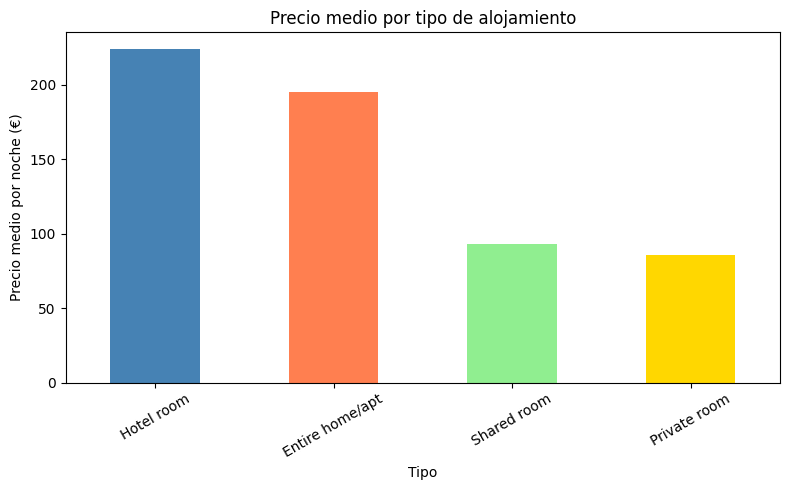

In [10]:
precio_por_tipo = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
precio_por_tipo.plot(kind='bar', color=['steelblue', 'coral', 'lightgreen', 'gold'])
plt.title('Precio medio por tipo de alojamiento')
plt.xlabel('Tipo')
plt.ylabel('Precio medio por noche (€)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

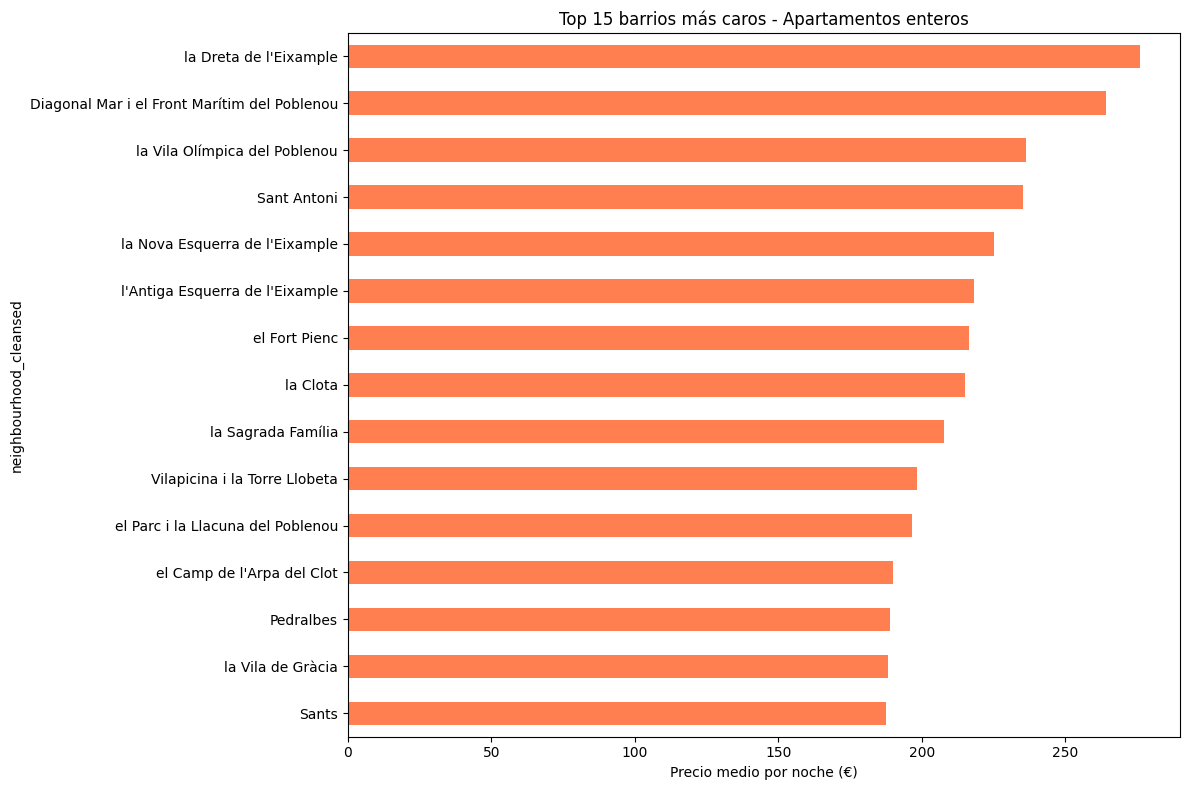

In [11]:
df_apt = df[df['room_type'] == 'Entire home/apt']

precio_apt_barrio = df_apt.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
precio_apt_barrio.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 barrios más caros - Apartamentos enteros')
plt.xlabel('Precio medio por noche (€)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
precio_disponibilidad = df.groupby('neighbourhood_cleansed').agg(
    precio_medio=('price', 'mean'),
    disponibilidad_media=('availability_365', 'mean'),
    reseñas_media=('number_of_reviews', 'mean')
).sort_values('reseñas_media', ascending=False)

print(precio_disponibilidad.head(10))

                                    precio_medio  disponibilidad_media  \
neighbourhood_cleansed                                                   
Hostafrancs                           162.875000            215.052632   
el Camp d'en Grassot i Gràcia Nova    139.847458            211.762712   
el Parc i la Llacuna del Poblenou     165.648148            229.586420   
el Poble Sec                          149.628111            223.872621   
la Sagrada Família                    171.477117            219.524027   
la Dreta de l'Eixample                226.576440            228.065445   
la Maternitat i Sant Ramon            127.519481            254.688312   
la Vila de Gràcia                     159.843683            230.937901   
el Fort Pienc                         178.732468            227.662338   
Sant Antoni                           199.595297            235.279703   

                                    reseñas_media  
neighbourhood_cleansed                             
Hostafr

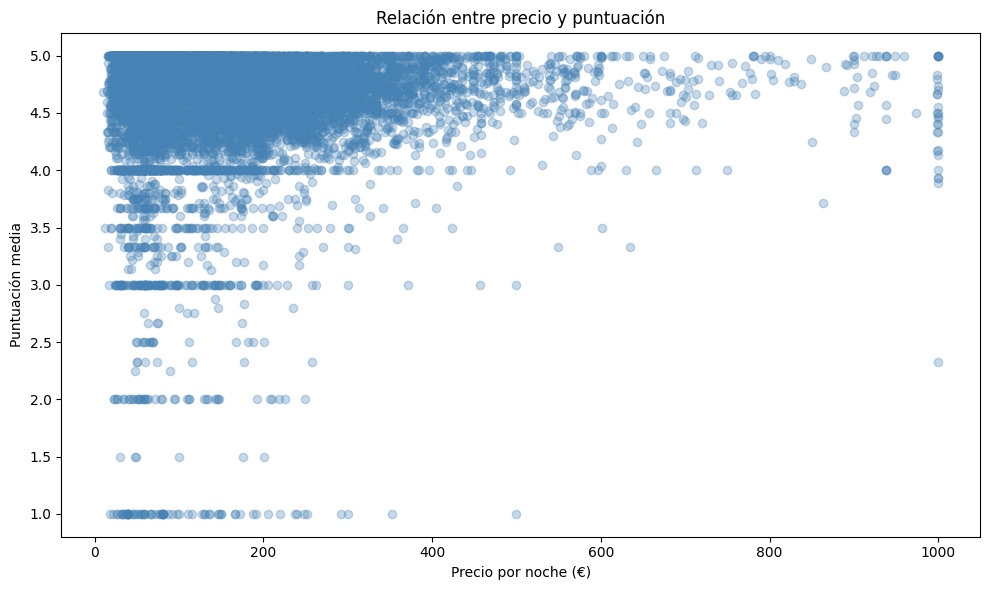

In [13]:
df_clean = df.dropna(subset=['review_scores_rating'])

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['price'], df_clean['review_scores_rating'], alpha=0.3, color='steelblue')
plt.title('Relación entre precio y puntuación')
plt.xlabel('Precio por noche (€)')
plt.ylabel('Puntuación media')
plt.tight_layout()
plt.show()